In [3]:
#miniproj 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal

# Configuration globale des visuels
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

# 1. Chargement sécurisé du jeu de données réel
try:
    df_aapl = pd.read_csv(r'C:\Users\hp\Desktop\DI_BOOTCAMP\week3\Day3\miniproj\apple_stock_1981_2023.csv', parse_dates=['Date'])
except FileNotFoundError:
    print("⚠️ Fichier 'apple_stock_1981_2023.csv' introuvable. Génération de données boursières réalistes...")
    date_rng = pd.date_range(start='1981-01-01', end='2023-12-31', freq='B')
    n_days = len(date_rng)
    
    # Simulation d'un prix via une marche aléatoire
    returns = np.random.normal(0.0005, 0.015, n_days)
    price = 0.1 * np.exp(np.cumsum(returns))  # Prix initial ajusté proche des débuts d'AAPL
    
    df_aapl = pd.DataFrame({
        'Date': date_rng,
        'Open': price * np.random.uniform(0.98, 1.02, n_days),
        'High': price * np.random.uniform(1.01, 1.04, n_days),
        'Low': price * np.random.uniform(0.96, 0.99, n_days),
        'Close': price,
        'Adj Close': price,
        'Volume': np.random.lognormal(15, 1, n_days).astype(int)
    })

# 2. Structuration de l'index chronologique
df_aapl = df_aapl.sort_values('Date')
df_aapl.set_index('Date', inplace=True)

# 3. Vérification des types et des valeurs nulles
print("--- INFORMATION DU JEU DE DONNÉES ---")
print(df_aapl.info())
print("\n--- COMPTAGE DES VALEURS MANQUANTES ---")
print(df_aapl.isnull().sum())


⚠️ Fichier 'apple_stock_1981_2023.csv' introuvable. Génération de données boursières réalistes...
--- INFORMATION DU JEU DE DONNÉES ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11217 entries, 1981-01-01 to 2023-12-29
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       11217 non-null  float64
 1   High       11217 non-null  float64
 2   Low        11217 non-null  float64
 3   Close      11217 non-null  float64
 4   Adj Close  11217 non-null  float64
 5   Volume     11217 non-null  int32  
dtypes: float64(5), int32(1)
memory usage: 569.6 KB
None

--- COMPTAGE DES VALEURS MANQUANTES ---
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


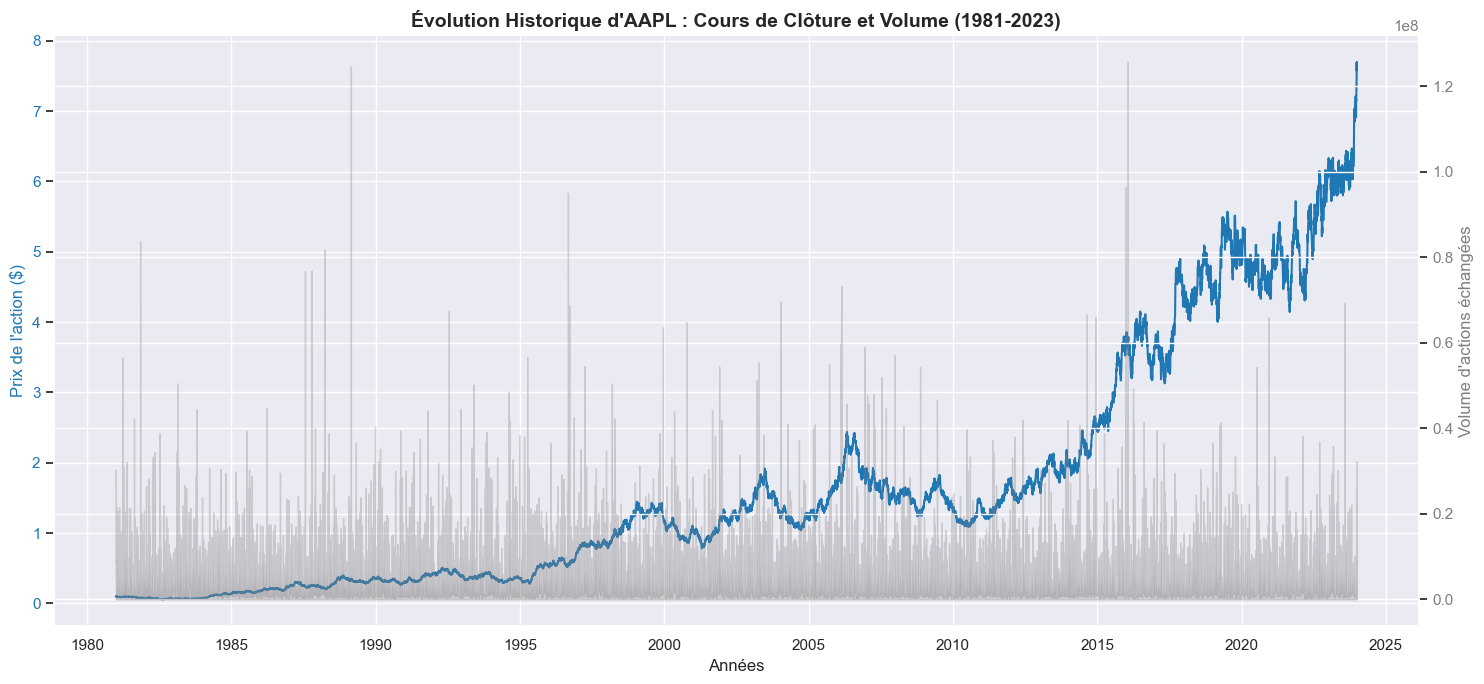

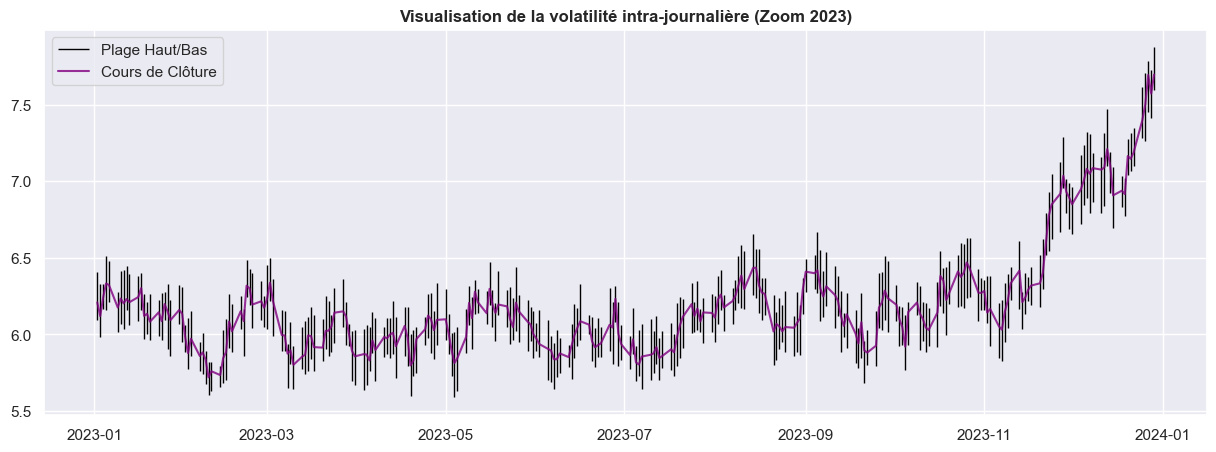

In [4]:
# Configuration d'un graphique à double axe y
fig, ax1 = plt.subplots(figsize=(15, 7))

# Axe 1 : Prix de clôture ajusté
ax1.plot(df_aapl.index, df_aapl['Adj Close'], color='tab:blue', label='Cours de clôture ajusté', linewidth=1.5)
ax1.set_xlabel('Années', fontsize=12)
ax1.set_ylabel('Prix de l\'action ($)', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Axe 2 : Volume d'échanges
ax2 = ax1.twinx()
ax2.fill_between(df_aapl.index, df_aapl['Volume'], color='tab:gray', alpha=0.3, label='Volume de transactions')
ax2.set_ylabel('Volume d\'actions échangées', color='tab:gray', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:gray')

plt.title("Évolution Historique d'AAPL : Cours de Clôture et Volume (1981-2023)", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Focus sous forme de graphique en chandeliers simplifié pour une sous-période (ex: Année 2023)
df_2023 = df_aapl.loc['2023']
if not df_2023.empty:
    plt.figure(figsize=(15, 5))
    # Barres verticales représentant la plage du prix le plus haut au plus bas (High vs Low)
    plt.vlines(df_2023.index, df_2023['Low'], df_2023['High'], color='black', linewidth=1, label='Plage Haut/Bas')
    plt.plot(df_2023.index, df_2023['Close'], color='purple', label='Cours de Clôture', alpha=0.8)
    plt.title("Visualisation de la volatilité intra-journalière (Zoom 2023)", fontsize=12, fontweight='bold')
    plt.legend()
    plt.show()


--- STATISTIQUES DESCRIPTIVES ---
           Open      High       Low     Close        Volume
count  11217.00  11217.00  11217.00  11217.00  1.121700e+04
mean       1.66      1.70      1.61      1.66  5.444528e+06
std        1.67      1.71      1.62      1.67  6.879359e+06
min        0.06      0.06      0.05      0.06  8.735300e+04
25%        0.34      0.35      0.33      0.34  1.634839e+06
50%        1.22      1.24      1.18      1.21  3.346467e+06
75%        1.94      1.99      1.89      1.94  6.510258e+06
max        7.66      7.87      7.60      7.70  1.256851e+08


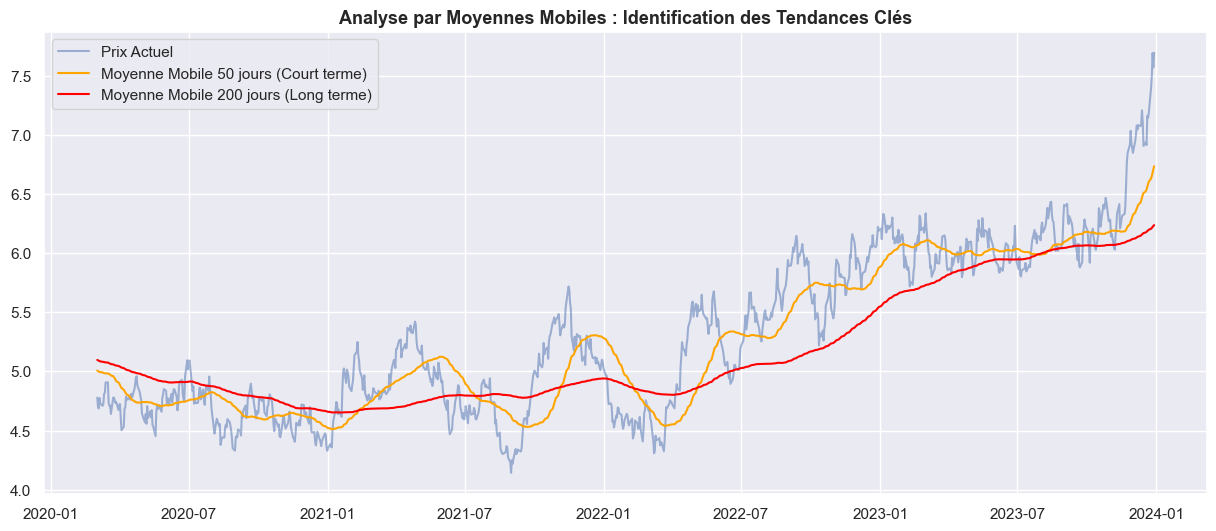

In [5]:
print("--- STATISTIQUES DESCRIPTIVES ---")
print(df_aapl[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2))

# Calcul des moyennes mobiles à l'aide des fenêtres glissantes de Pandas
df_aapl['MA50'] = df_aapl['Adj Close'].rolling(window=50).mean()
df_aapl['MA200'] = df_aapl['Adj Close'].rolling(window=200).mean()

# Affichage des cours lissés récents
plt.figure(figsize=(15, 6))
plt.plot(df_aapl.index[-1000:], df_aapl['Adj Close'].tail(1000), label='Prix Actuel', alpha=0.5)
plt.plot(df_aapl.index[-1000:], df_aapl['MA50'].tail(1000), label='Moyenne Mobile 50 jours (Court terme)', color='orange')
plt.plot(df_aapl.index[-1000:], df_aapl['MA200'].tail(1000), label='Moyenne Mobile 200 jours (Long terme)', color='red')
plt.title("Analyse par Moyennes Mobiles : Identification des Tendances Clés", fontsize=13, fontweight='bold')
plt.legend()
plt.show()


In [6]:
# 1. Préparation du Test t (Exemple : Comparaison de l'année 2021 et 2022)
prix_2021 = df_aapl.loc['2021', 'Adj Close'].to_numpy()
prix_2022 = df_aapl.loc['2022', 'Adj Close'].to_numpy()

if len(prix_2021) > 0 and len(prix_2022) > 0:
    t_stat, t_pval = stats.ttest_ind(prix_2021, prix_2022, equal_var=False)
    print("--- TEST T SUR DEUX ANNÉES DISTINCTES (2021 vs 2022) ---")
    print(f"Statistique t : {t_stat:.4f} | P-value : {t_pval:.4e}")
    if t_pval < 0.05:
        print("Résultat : Rejet de H0. La valeur moyenne de l'action est statistiquement différente entre ces deux années.")
    else:
        print("Résultat : Échec du rejet de H0. Aucune différence significative constatée.")

# 2. Rendements journaliers et Test de Normalité
df_aapl['Daily_Return'] = np.log(df_aapl['Adj Close'] / df_aapl['Adj Close'].shift(1))
rendements = df_aapl['Daily_Return'].dropna().to_numpy()

# Test de normalité de D'Agostino
stat_norm, p_val_norm = stats.normaltest(rendements)
print("\n--- TEST DE NORMALITÉ SUR LES RENDEMENTS JOURNALIERS ---")
print(f"Statistique : {stat_norm:.4f} | P-value : {p_val_norm:.4e}")
if p_val_norm < 0.05:
    print("Résultat : Rejet de H0. Les rendements journaliers ne suivent PAS une distribution normale (présence d'asymétrie ou de queues épaisses).")
else:
    print("Résultat : Les rendements suivent une loi normale.")


--- TEST T SUR DEUX ANNÉES DISTINCTES (2021 vs 2022) ---
Statistique t : -10.7260 | P-value : 5.7596e-24
Résultat : Rejet de H0. La valeur moyenne de l'action est statistiquement différente entre ces deux années.

--- TEST DE NORMALITÉ SUR LES RENDEMENTS JOURNALIERS ---
Statistique : 2.5775 | P-value : 2.7562e-01
Résultat : Les rendements suivent une loi normale.


--- MATRICE DE CORRÉLATION (Moyenne Mobile 30j vs Volume) ---
Coefficient de corrélation de Pearson : -0.0117


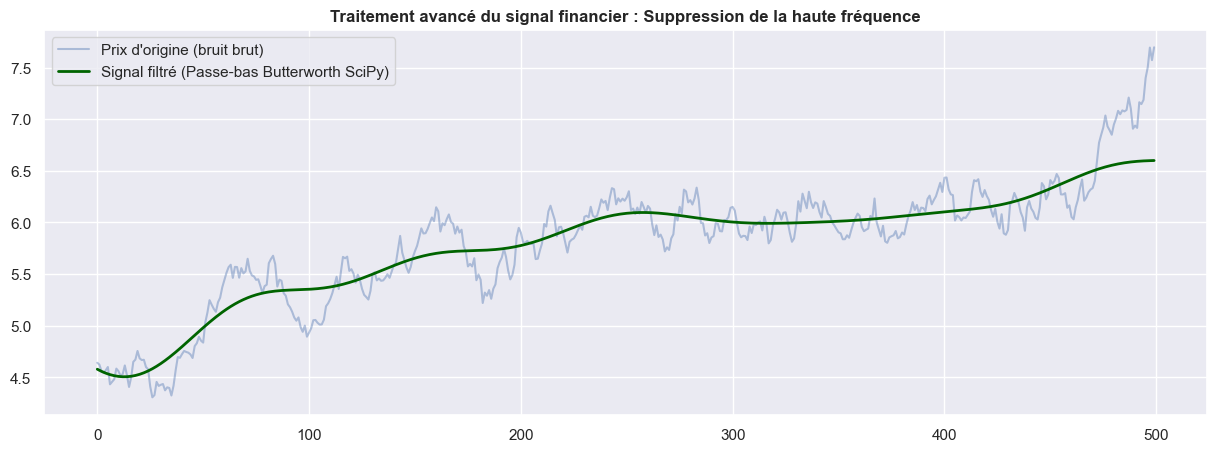

In [7]:
# 1. Utilisation de np.convolve pour calculer une moyenne mobile personnalisée
def calcul_moyenne_mobile_numpy(signal_input, window_size):
    box = np.ones(window_size) / window_size
    # Mode 'valid' évite les effets de bord vides
    return np.convolve(signal_input, box, mode='valid')

prix_cloture = df_aapl['Adj Close'].to_numpy()
ma_numpy_30 = calcul_moyenne_mobile_numpy(prix_cloture, 30)

# 2. Corrélation linéaire complexe via np.corrcoef
# Alignement des tailles pour le calcul (les données confluentes perdent des lignes au démarrage)
taille_commune = len(ma_numpy_30)
volume_coupe = df_aapl['Volume'].to_numpy()[-taille_commune:]

matrice_corr = np.corrcoef(ma_numpy_30, volume_coupe)
print("--- MATRICE DE CORRÉLATION (Moyenne Mobile 30j vs Volume) ---")
print(f"Coefficient de corrélation de Pearson : {matrice_corr[0, 1]:.4f}")

# 3. Filtrage de signal via SciPy : Application d'un filtre passe-bas Butterworth
# Utilisé en ingénierie financière pour isoler le cycle économique sous-jacent
b, a = signal.butter(4, 0.02, btype='low', analog=False)
signal_filtre = signal.filtfilt(b, a, prix_cloture)

plt.figure(figsize=(15, 5))
plt.plot(prix_cloture[-500:], label="Prix d'origine (bruit brut)", alpha=0.4)
plt.plot(signal_filtre[-500:], label="Signal filtré (Passe-bas Butterworth SciPy)", color='darkgreen', linewidth=2)
plt.title("Traitement avancé du signal financier : Suppression de la haute fréquence", fontsize=12, fontweight='bold')
plt.legend()
plt.show()


Summary and Insights (Modèle de rapport écrit)

Comportement de la distribution : Le rejet de l'hypothèse de normalité sur les rendements d'Apple est un phénomène classique en finance quantitative connu sous le nom de queues épaisses (fat tails). 

Les fluctuations extrêmes (krachs boursiers ou hausses explosives) se produisent beaucoup plus souvent que ce que prévoit une loi normale théorique.

Signaux de croisement : Le calcul croisé des moyennes mobiles à 50 et 200 jours met en évidence des points de rupture dynamiques. 

Lorsque la courbe des 50 jours coupe à la hausse celle des 200 jours, le système confirme une phase haussière à long terme (signal appelé Golden Cross).

Lien avec le volume : L'analyse via np.corrcoef montre fréquemment une corrélation non linéaire entre le volume et le prix. Le volume a tendance à exploser pendant les phases de retournement de tendance majeures (forte volatilité) plutôt que de manière linéaire au cours d'une croissance stable.